# Notebook Objectives

 - Handle Data that is across different experiments (numbers of latents)
 - Nominally these are:
    - PLotting of loss as a function of latent dimension
    - Creating super trajectories for making movies of reconstruction

In [1]:
import json, os, jax, glob
import jax.numpy as jnp
import mdtraj as md
import matplotlib.pyplot as plt
import numpy as np
from pyscripts.analysis import NN_Experiment_Analyzer, ND_NN_Experiment_Analyzer
#import pyscripts.jax_amber3 as jaa

jax:    0.4.30
jaxlib: 0.4.30
numpy:  1.26.4
python: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
jax.devices (1 total, 1 local): [CpuDevice(id=0)]
process_count: 1
platform: uname_result(system='Linux', node='quickly-beloved-salmon', release='5.15.0-113-generic', version='#123-Ubuntu SMP Mon Jun 10 08:16:17 UTC 2024', machine='x86_64')



/media/volume/Joseph-Large2/githubs/Deep-MMS/pyscripts/jax_amber3.py:11: SyntaxWarning: invalid escape sequence '\('
  FORMAT_RE_PATTERN=re.compile("([0-9]+)\(?([a-zA-Z]+)([0-9]+)\.?([0-9]*)\)?")


In [2]:
def atom_rmsd(a, b, potential_coefficient=None): # for arrays of (n_conf, n_atom*3)
    mn = a.shape[-1]//3
    x_inds, y_inds, z_inds = jnp.arange(0,mn), jnp.arange(mn, 2*mn), jnp.arange(2*mn, 3*mn)
    return jnp.sqrt(jnp.mean((b[x_inds] - a[x_inds])**2 + (b[y_inds] - a[y_inds])**2 + (b[z_inds] - a[z_inds])**2))

#gas_fun, _ = jaa.get_amber_functions('Simulation/ala_deca_peptide.prmtop')
def scaled_pot_enr_diff(a, b, potential_coefficient=None): # WITH A AS BATCH AND B AS RECON
    return ((gas_fun(a) - gas_fun(b))/gas_fun(a))**2 #Unitless quantity

class NN_Multi_Analyzer():
    def __init__(self, json_params_series:[dict], netcdf_fns:[str], checkpoint_dirs:[str], analyzer=NN_Experiment_Analyzer):
        assert len(json_fns) == len(netcdf_fns)
        assert len(json_fns) == len(checkpoint_dirs)

        self.experiments = {}

        for i in range(len(netcdf_fns)):
            exp = analyzer(json_params_series[i], netcdf_fns[i], checkpoint_dirs[i])
            key = f"{exp.n_latents} Latents"
            self.experiments[key] = exp

    def super_traj_construct(self, rng_seed, n_frames=500, mode='Decoded', num_components=None):
        """
        Creates two trajectories, which can be simultaneously visualized to see reconstruction with different numbers of latents

        Parameters:
            n_frames: The number of frames from each set to use, will be a slice of every x frames of the test data such that there are n_frames
                      i.e. if test_data is size 2000, and 500 frames are requested, every fourth frame of the test set will be shown
            mode: string in ['Decoded', 'Modeled'] : If Decoded, the super traj will contain frames that were encoded and decoded by the NN
                                                     If Modeled, the super traj will contain frames generated by GMM
            num_components: if not None, must be a list of integers the same length as the number of experiments
                            Will generate samples from the Gaussian Mixture Model to compare to
        """
        assert mode in ['Decoded', 'Modeled']
        #Since all experiments should have the same numbers of dimensions in this analysis, the atomistic size will be obtained from only one
        #size_test_set = pass
        num_experiments = len(self.experiments)
        if mode == 'Modeled':
            assert num_components is not None
            assert type(num_components) == list
            assert len(num_components) == num_experiments
            assert False not in [type(num) == int for num in num_components]
        num_test_set, num_dimensions = list(self.experiments.values())[0].test_data.shape
        #print(num_test_set, num_dimensions)
        assert num_test_set % n_frames == 0
        super_traj_test = jnp.zeros((n_frames*num_experiments, num_dimensions))
        super_traj_comp = jnp.zeros((n_frames*num_experiments, num_dimensions))

        for i in range(num_experiments):
            indices = jnp.arange(0, num_test_set, num_test_set//n_frames)
            #print(indices.shape)
            #print(indices)
            test_data = list(self.experiments.values())[i].test_data
            super_traj_test = super_traj_test.at[i*n_frames:(i+1)*n_frames, :].set(test_data[indices, :])

            if mode == 'Decoded':
                comp_data, _ = list(self.experiments.values())[i].operate(rng_seed)
            elif mode == 'Modeled':
                _, comp_data = list(self.experiments.values())[i].gaussian_mm_fit(rng_seed, num_components[i])

            super_traj_comp = super_traj_comp.at[i*n_frames:(i+1)*n_frames, :].set(comp_data[indices, :])

        assert not jnp.any(super_traj_comp == 0.0) and not jnp.any(super_traj_test == 0.0)
        return super_traj_test, super_traj_comp

    def rmsd_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, rmsds = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
        latents, rmsds = jnp.array(latents), jnp.array(rmsds)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        figure(figsize=(3.25, 3), dpi=80)
        plt.rc('font', **{'family' : 'normal', 'weight' : 'bold', 'size'   : 11})
        parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('RMSD (Angstrom)')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()

    def potential_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, pots = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            pots.append(jax.jit(scaled_pot_enr_diff)(exp.test_data, recon))
        latents, pots = jnp.array(latents), jnp.array(pots)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        parts = plt.violinplot(jnp.sqrt(pots), pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('Potential Deviation (%)')
        plt.yscale('log')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()
            
        

In [3]:
rpt = 1
bromo_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_20_24/jsons/3mxf_*{rpt}.json',
               f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
               f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
dapot_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_15_24/jsons/*{rpt}.json',
               f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/*checkpoint.nc',
               f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
darmsd_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/jsons/DA*{rpt}.json',
                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
crrmsd_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/jsons/Crambin_AE_*{rpt}.json',
                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default']
HIV1p_cards = [f'HIV1p_AE_Dropout_RMSD_only/jsons/*{rpt}.json',
               f'HIV1p_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
               f'HIV1p_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
oxy_cards = [f'/media/volume/Aryan-s-Volume/Deep-MMS/bridges2_runs/Oxycodone_RMSD_only/*{rpt}.json',
             f'/media/volume/Aryan-s-Volume/Deep-MMS/bridges2_runs/Oxycodone_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
             f'/media/volume/Aryan-s-Volume/Deep-MMS/bridges2_runs/Oxycodone_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default']
da_noDrop_rmsd_cards = [f'/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/*{rpt}.json',
                        f'/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/*_latents/rpt_{rpt}/*checkpoint.nc',
                        f'/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']

#Use the following rpt for each, respectively, 3, 0, 0, 0, 0, 0, 1, 


json_wildcard, nc_wildcard, ckpt_wildcard = da_noDrop_rmsd_cards
system = 'Deca-Alanine No-Dropouts'



json_fns = sorted(glob.glob(json_wildcard))
netcdf_fns = sorted(glob.glob(nc_wildcard))
all_checkpoint_dirs = sorted(glob.glob(ckpt_wildcard))

checkpoint_dirs = []
#Two checkpoints per model, always take the latest one
indices = range(1, len(all_checkpoint_dirs)+1, 2)
for ind in indices:
    checkpoint_dirs.append(all_checkpoint_dirs[ind])

assert len(json_fns) == len(netcdf_fns)
assert len(json_fns) == len(checkpoint_dirs)

In [5]:
for i in range(len(json_fns)):
    print(json_fns[i])
    print(netcdf_fns[i])
    print(checkpoint_dirs[i])
    print('#########################################################')

/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/DA_AE_NO-Dropout_RMSD_0001_1.json
/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/0001_latents/rpt_1/model_DA_AE_NO-Dropout_RMSD_0001_checkpoint.nc
/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/0001_latents/rpt_1/checkpoint_managed/99800/default/
#########################################################
/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/DA_AE_NO-Dropout_RMSD_0002_1.json
/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/0002_latents/rpt_1/model_DA_AE_NO-Dropout_RMSD_0002_checkpoint.nc
/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/0002_latents/rpt_1/checkpoint_managed/93400/default/
#########################################################
/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/DA_AE_NO-Dropout_RMSD_0004_1.json
/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/0004_lat

In [6]:
json_params_series = []
for json_fn in json_fns:
    #Json files were on Bridges2, doctor for this analysis
    with open(json_fn, 'r') as f:
        json_params = json.load(f)
    #print(json_params)
    #the json is from bridges, change file paths to be from jetstream
    #/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/ -> /media/volume/sdb/githubs/Deep-MMS/
    for key in ["fname_dcd", "fname_prmtop", "save_dir"]:
        json_params[key] = json_params[key].replace("/ocean/projects/mcb160011p/josephdb/",
                                                    "/media/volume/Joseph-Large/")
        json_params[key] = json_params[key].replace("/ocean/projects/mcb160011p/abahl/",
                                                    "/media/volume/Aryan-s-Volume/")
        #print(os.path.isfile(json_params[key]))
    #print(json_params)
    json_params_series.append(json_params)

In [7]:
self = NN_Multi_Analyzer(json_params_series, netcdf_fns, checkpoint_dirs, analyzer=ND_NN_Experiment_Analyzer)

Load Files
{'fname_dcd': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/decaalanine_1us_split7.dcd', 'fname_prmtop': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/ala_deca_peptide.prmtop', 'fname_pdb': 'None', 'save_dir': '/media/volume/Joseph-Large/githubs/Deep-MMS/', 'data_dir': 'None', 'max_epoch': 100000, 'latent_dim': 1, 'test_slice': 1, 'data_slice_start': 0, 'data_slice_end': 'None', 'model_name': 'DA_AE_NO-Dropout_RMSD', 'batch_size': 2000, 'learning_rate': 1e-06, 'dropout_rates': [0.0, 0.0, 0.0], 'potential_threshold': 10, 'model_type': 'AE', 'coordinate_scheme': 'Cartesian', 'resume_latest': False, 'report_potential': True, 'checkpoint_interval': 200}
Load Data with MDTraj
Batch data
(8000, 306) (2000, 306)
Model Init
Batch Data
Read NetCDF and Checkpoint
Load Files
{'fname_dcd': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/decaalanine_1us_split7.dcd', 'fname_prmtop': '/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/ala_deca_peptide.prmtop

In [8]:
def plot_results(exp):
    traingrp = exp.rootgrp['Train']
    testgrp = exp.rootgrp['Test']
    keys = ['RMSD']
    plt.clf()
    plt.title('RMSD' + f' {exp.n_latents} Latents')
    for grp in [traingrp, testgrp]:
        _ = plt.plot(np.arange(grp.variables['RMSD'][:, :].shape[0]),
                     np.mean(grp.variables['RMSD'][:, :], axis=1))
    plt.xlabel('Epoch')
    plt.ylabel('RMSD (nm)')
    plt.legend(['Train','Test'])
    plt.show()

    print(f'Num Epochs {traingrp.variables['RMSD'][:, :].shape[0]}')
    print(f'Last RMSD (nm): Train: {np.mean(traingrp.variables['RMSD'][-1, :])} Test {np.mean(testgrp.variables['RMSD'][-1, :])}')

In [9]:
for key, exp in self.experiments.items():
    print(key, exp.model)

1 Latents AE(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    dropout_rates = [0.0, 0.0, 0.0]
    latents = 1
)
2 Latents AE(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    dropout_rates = [0.0, 0.0, 0.0]
    latents = 2
)
4 Latents AE(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    dropout_rates = [0.0, 0.0, 0.0]
    latents = 4
)
8 Latents AE(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    dropout_rates = [0.0, 0.0, 0.0]
    latents = 8
)
16 Latents AE(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    dropout_rates = [0.0, 0.0, 0.0]
    latents = 16
)
32 Latents AE(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    dropout_rates = [0.0, 0.0, 0.0]
    latents = 32
)
64 Latents AE(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    dropout_rates = [0.0, 0.0, 0.0]
    latents = 64
)


1 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7efd80694440>


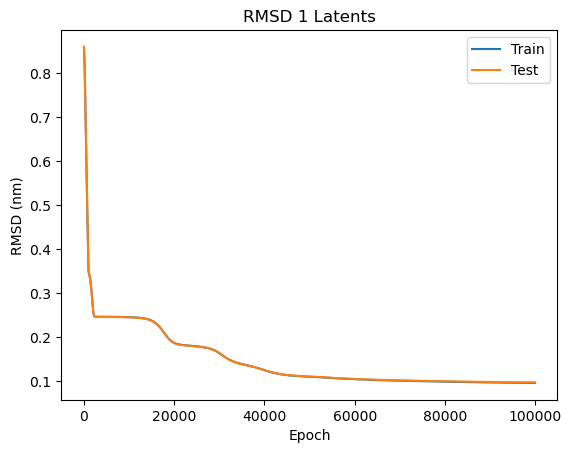

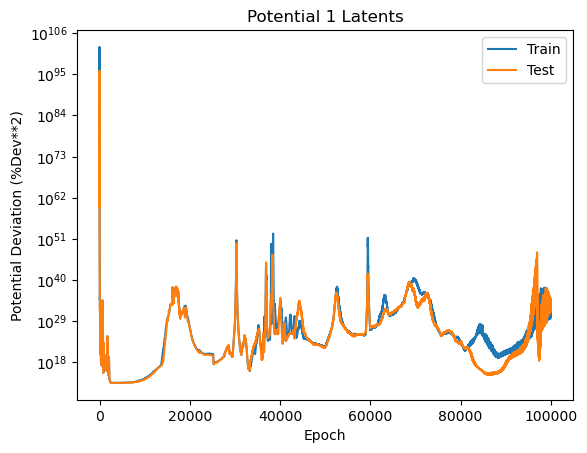

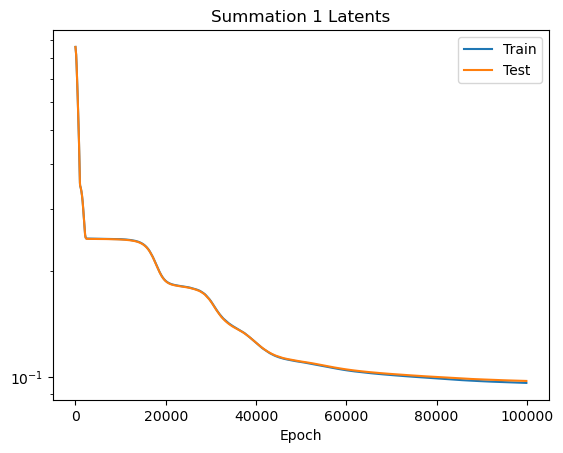

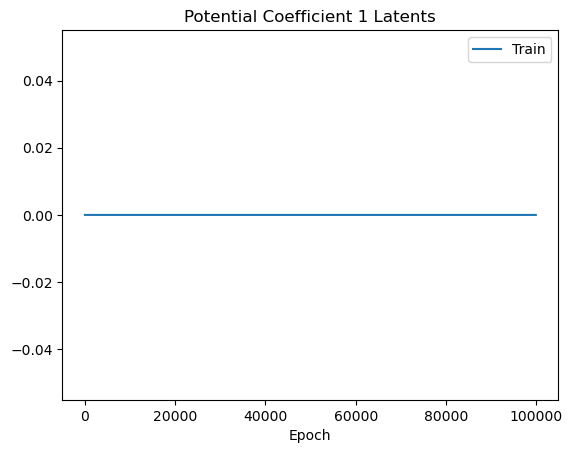

Num Epochs 99900
Last RMSD (nm): Train: 0.09645220637321472 Test 0.09770499914884567
Last PotDiff (% Deviation): Train: 5.2189175568819725e+31 Test 2.848757976622684e+34
2 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7efe0067a270>


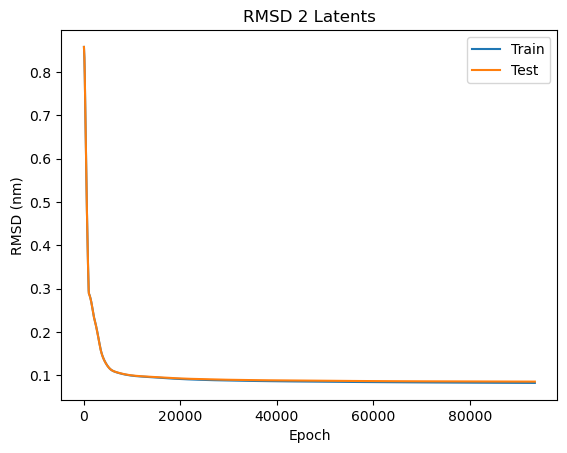

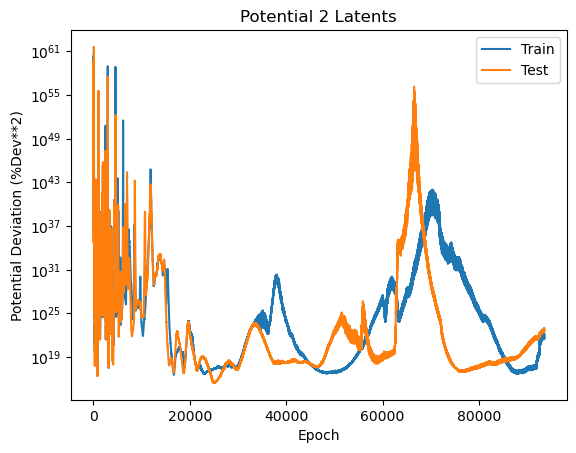

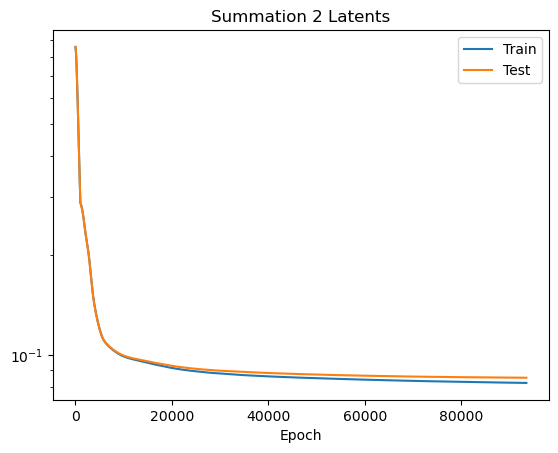

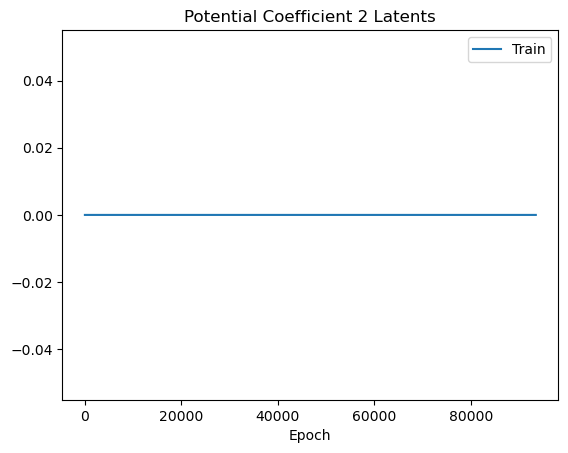

Num Epochs 93500
Last RMSD (nm): Train: 0.0820988267660141 Test 0.08512654900550842
Last PotDiff (% Deviation): Train: 4.403863213151715e+21 Test 9.024952646418253e+22
4 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7f01d4509a90>


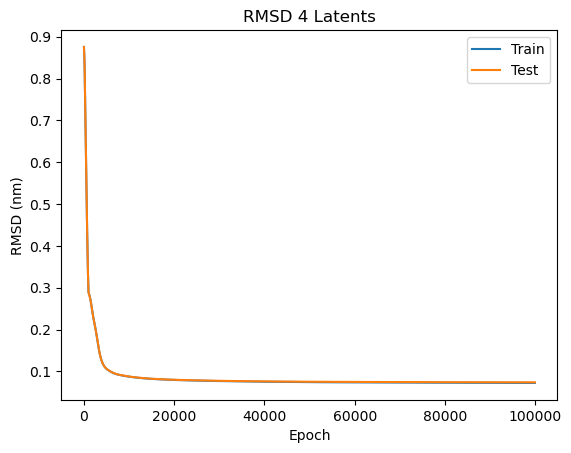

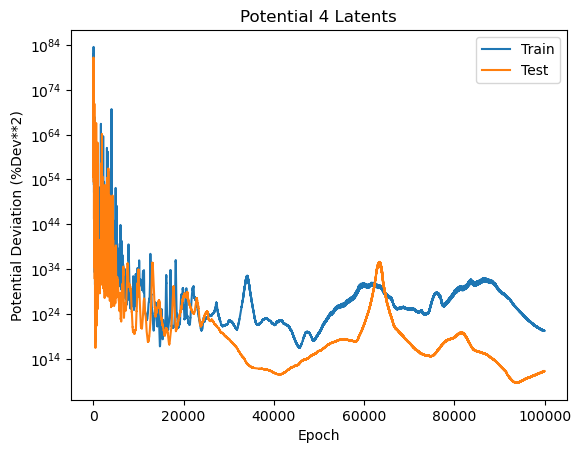

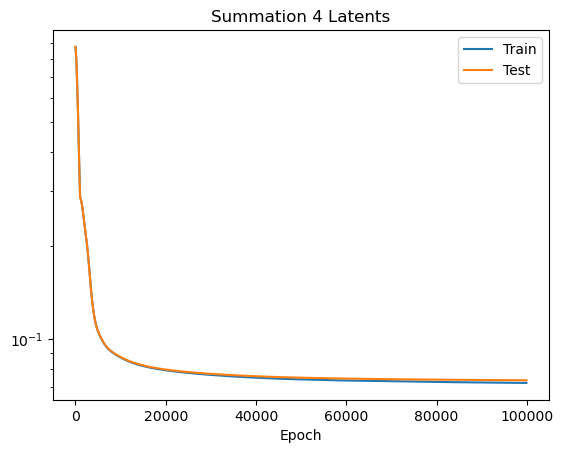

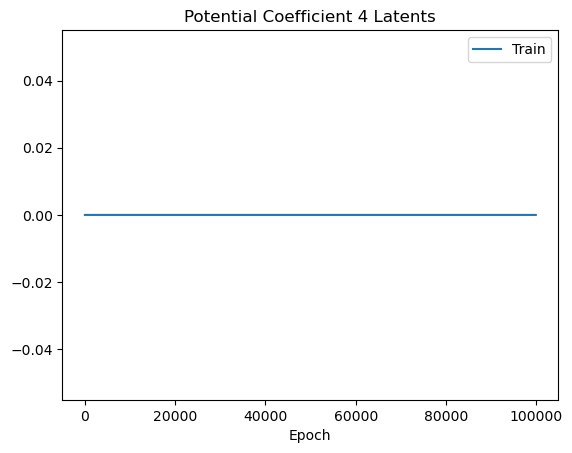

Num Epochs 99900
Last RMSD (nm): Train: 0.072309710085392 Test 0.07376250624656677
Last PotDiff (% Deviation): Train: 1.8840486311636468e+20 Test 191218332841.60208
8 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7efd80432750>


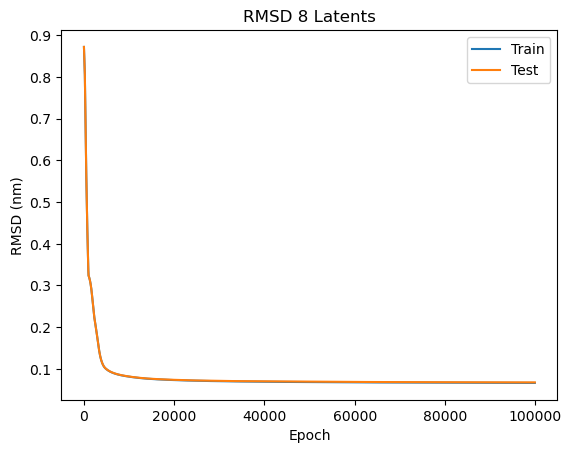

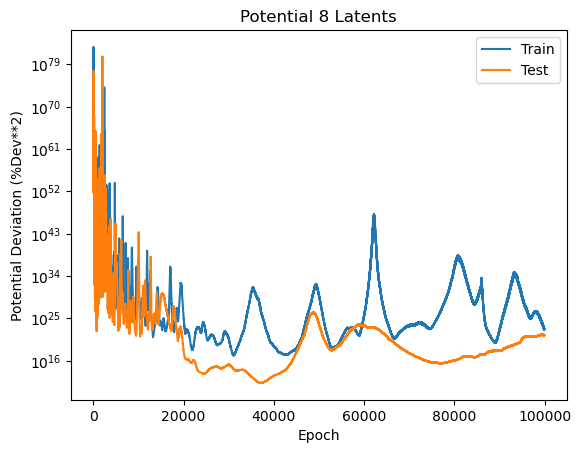

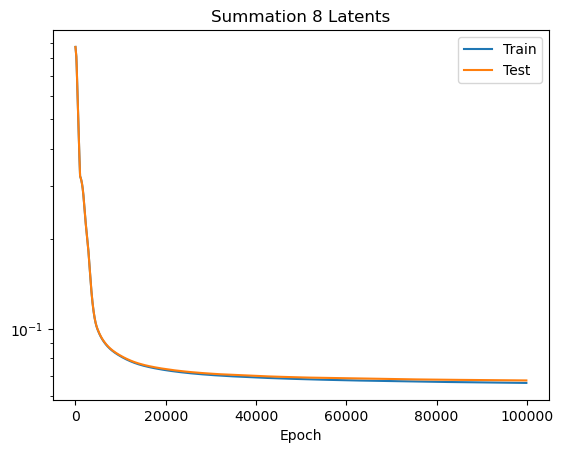

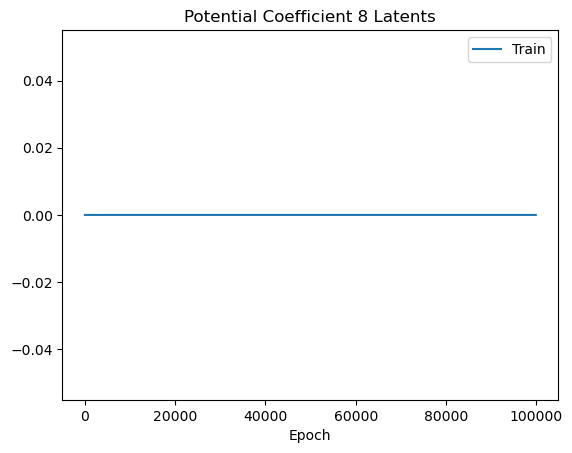

Num Epochs 99900
Last RMSD (nm): Train: 0.06622527539730072 Test 0.06750796735286713
Last PotDiff (% Deviation): Train: 5.5639741523408236e+22 Test 2.757602543987112e+21
16 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7efd6051f800>


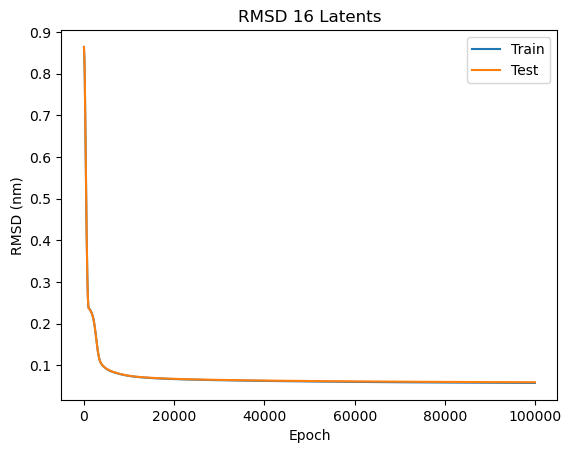

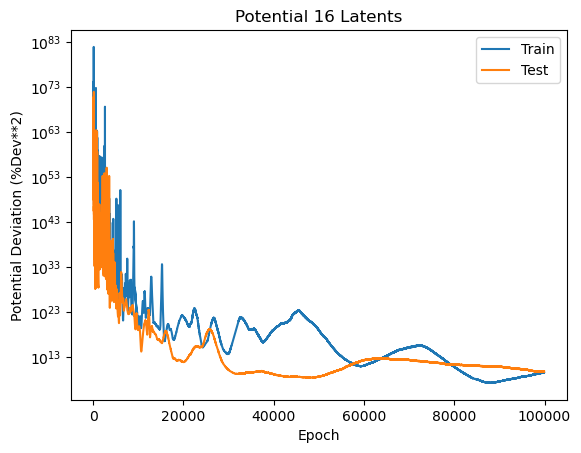

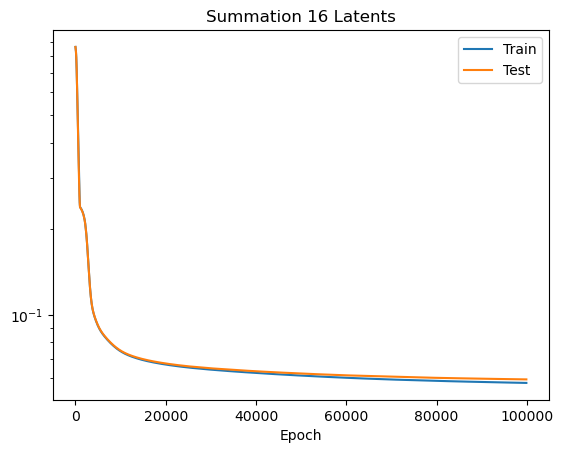

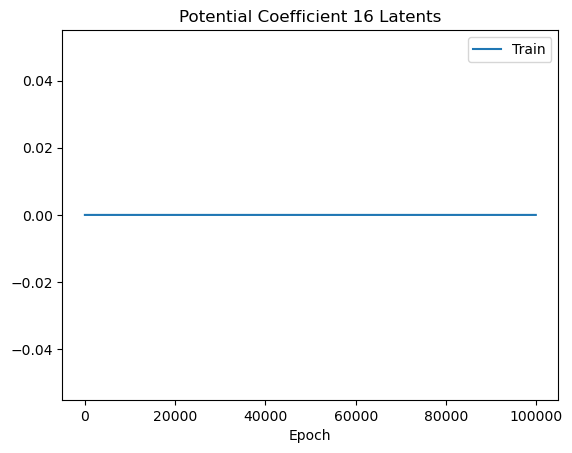

Num Epochs 99900
Last RMSD (nm): Train: 0.05774883180856705 Test 0.05941437929868698
Last PotDiff (% Deviation): Train: 3139840265.258063 Test 5438546545.70992
32 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7efd803cf770>


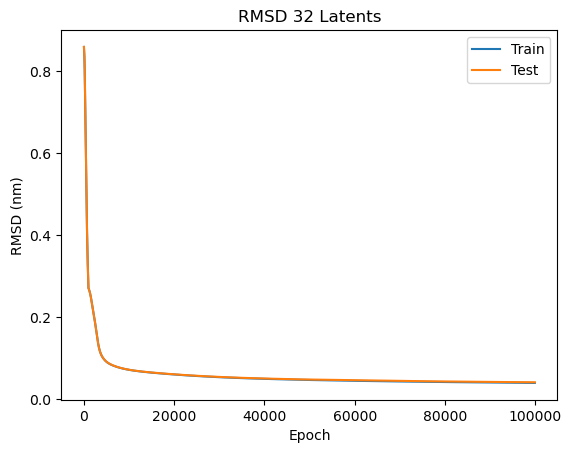

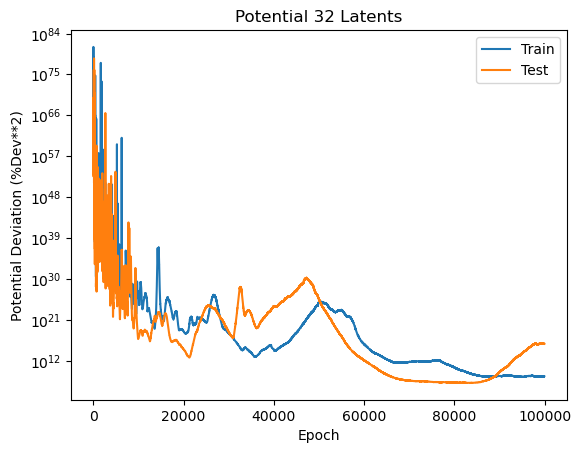

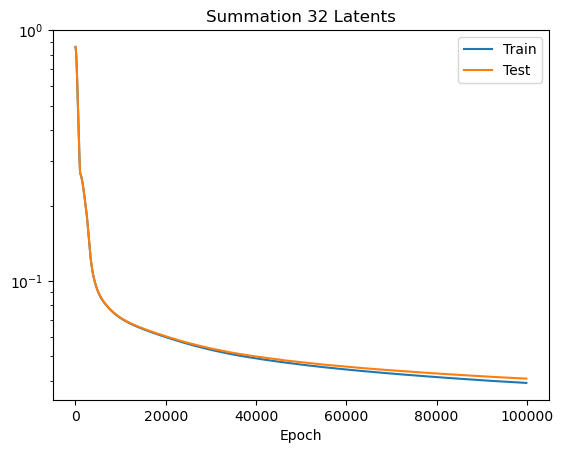

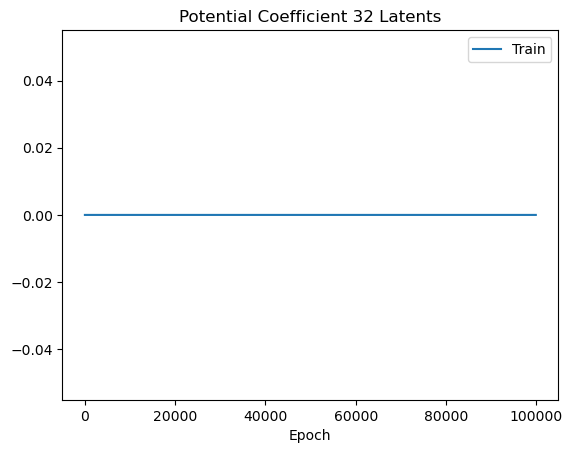

Num Epochs 99900
Last RMSD (nm): Train: 0.03920813277363777 Test 0.04078872129321098
Last PotDiff (% Deviation): Train: 344819162.40789956 Test 4889669424696027.0
64 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7efd60409160>


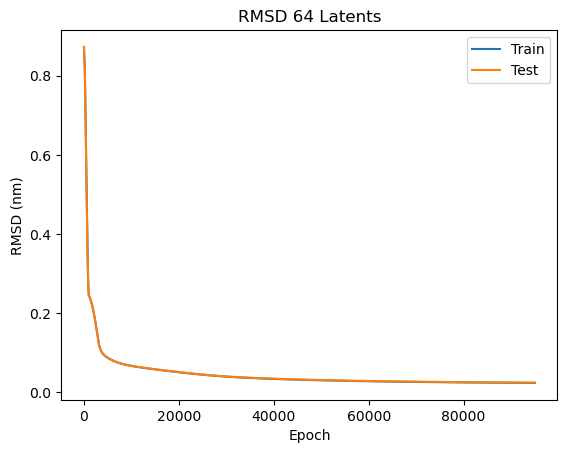

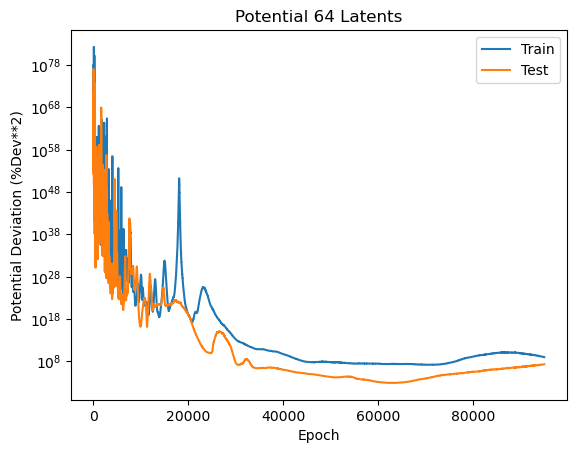

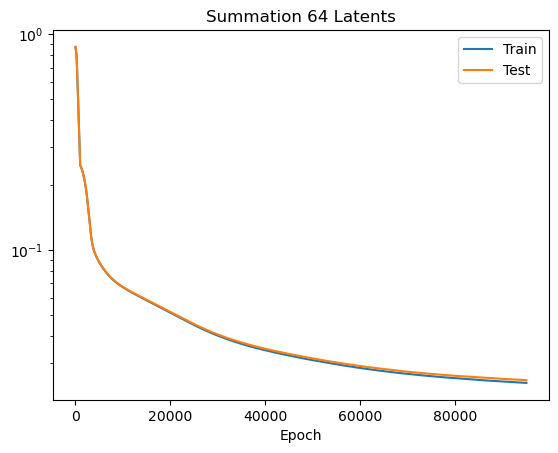

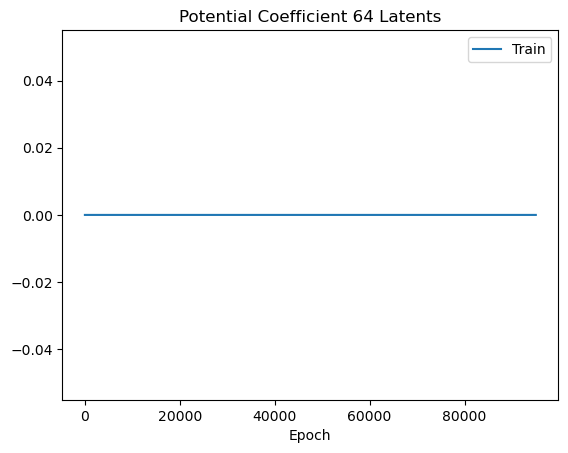

Num Epochs 95000
Last RMSD (nm): Train: 0.024159524589776993 Test 0.024879736825823784
Last PotDiff (% Deviation): Train: 1050524852.5280207 Test 21056318.301362608
128 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7efd8037c1d0>


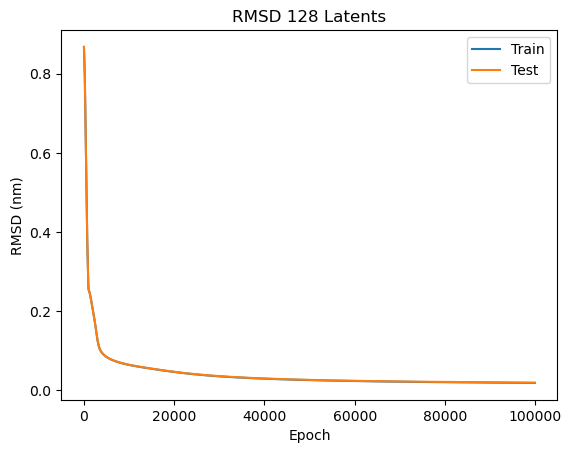

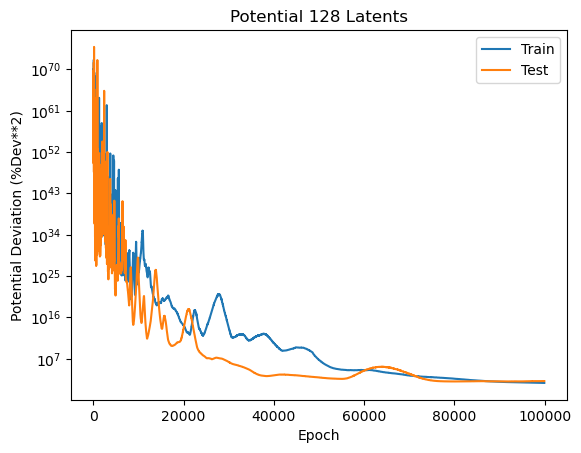

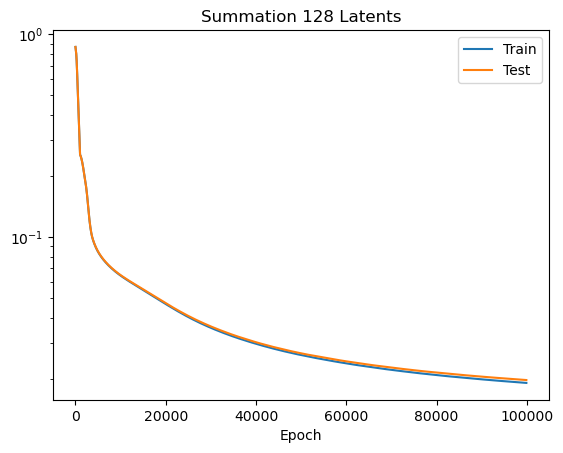

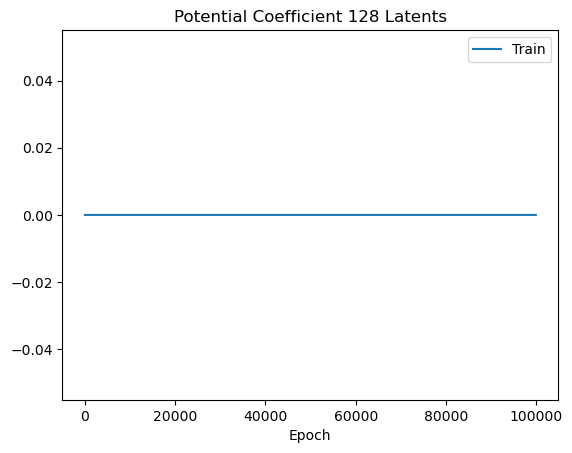

Num Epochs 99900
Last RMSD (nm): Train: 0.01904410496354103 Test 0.019677769392728806
Last PotDiff (% Deviation): Train: 48.187277301321906 Test 122.11257888469923
256 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7efd604c9670>


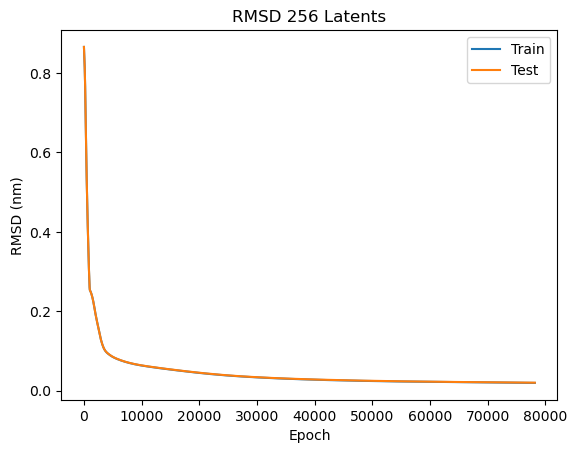

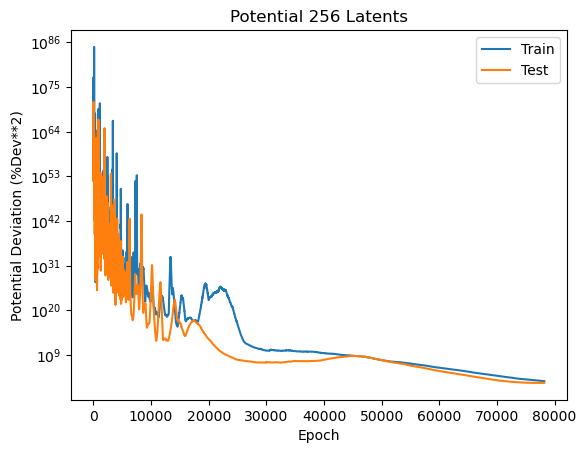

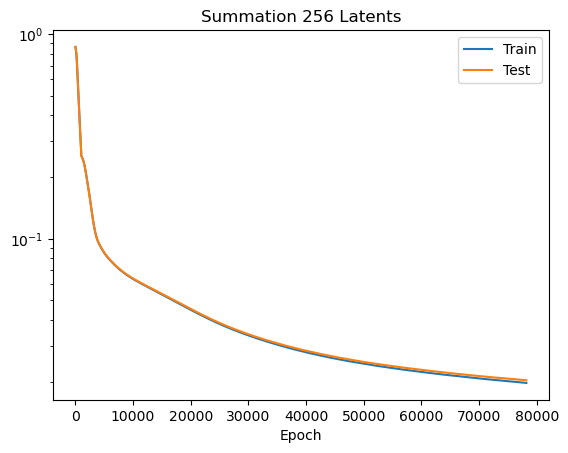

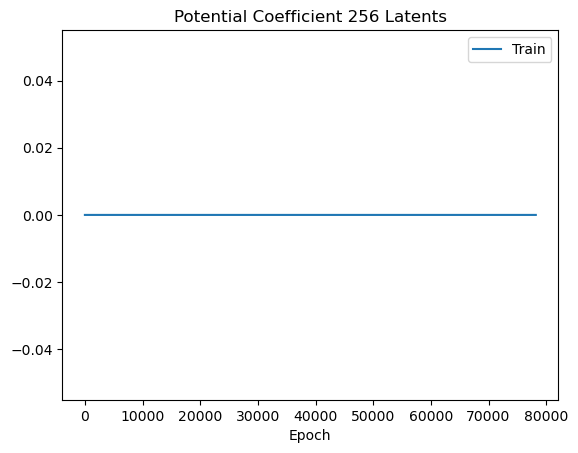

Num Epochs 78200
Last RMSD (nm): Train: 0.019721487537026405 Test 0.020322030410170555
Last PotDiff (% Deviation): Train: 381.76851096805086 Test 149.54089443578627
306 Latents <pyscripts.analysis.ND_NN_Experiment_Analyzer object at 0x7efd60442150>


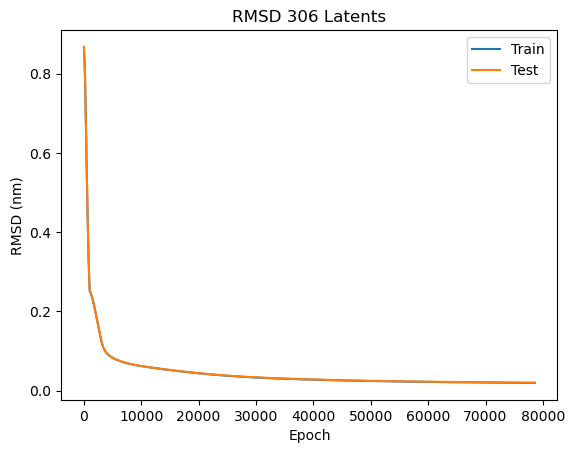

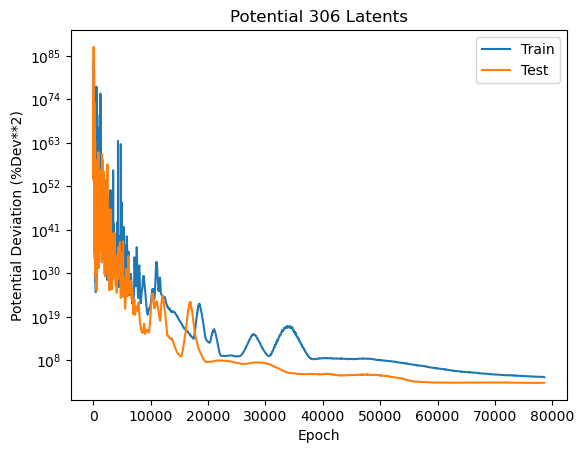

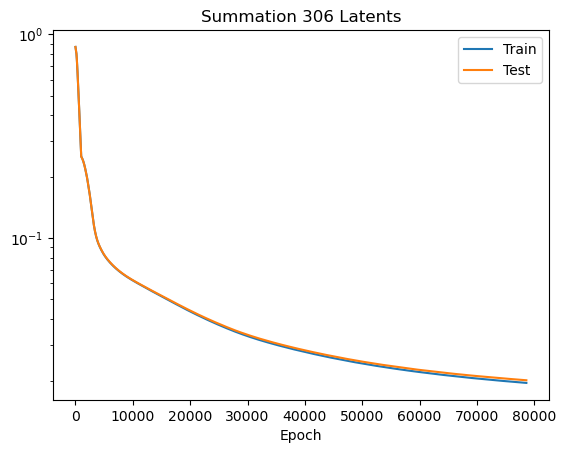

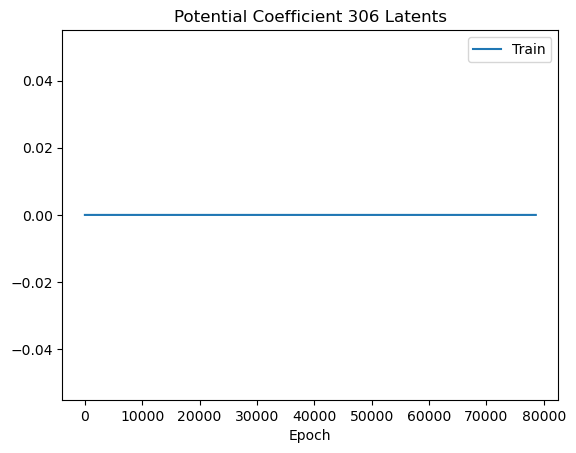

Num Epochs 78600
Last RMSD (nm): Train: 0.01946861296892166 Test 0.02006424218416214
Last PotDiff (% Deviation): Train: 4348.094355472548 Test 158.63228121851316


In [10]:
for key, exp in self.experiments.items():
    print(key, exp)
    exp.plot_results()

In [11]:
def rmsd_violin_plot(self, rng_seed, title):
    #Assemble the Data
    latents, rmsds = [], []
    for key, exp in self.experiments.items():
        print(key)
        latents.append(exp.n_latents)
        recon, _ = exp.operate(rng_seed)
        rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
    latents, rmsds = jnp.array(latents), jnp.array(rmsds)
    pos = jnp.log(latents) / jnp.log(2)
    #Make the Violin PLot
    plt.clf()
    plt.figure(figsize=(3.25, 3), dpi=80)
    plt.rc('font', **{'weight':'normal', 'size':11})
    parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_edgecolor('black')
        pc.set_alpha(1)
    plt.title(title)
    plt.ylabel('RMSD (Angstrom)')
    plt.xlabel('Num Latents (log base 2)')
    plt.xticks(pos[pos % 2 == 0])
    plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
    plt.show()

1 Latents
2 Latents
4 Latents
8 Latents
16 Latents
32 Latents
64 Latents
128 Latents
256 Latents
306 Latents


<Figure size 640x480 with 0 Axes>

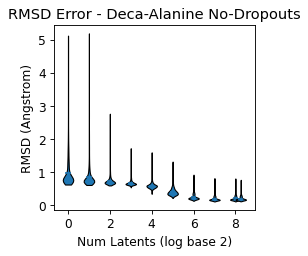

In [12]:
rmsd_violin_plot(self, rng_seed=98263, title=f'RMSD Error - {system}')

In [13]:
for key, exp in self.experiments.items():
    print(key, 'ran for:', len(exp.rootgrp['Train'].dimensions['epoch']), 'epochs')

1 Latents ran for: 99900 epochs
2 Latents ran for: 93500 epochs
4 Latents ran for: 99900 epochs
8 Latents ran for: 99900 epochs
16 Latents ran for: 99900 epochs
32 Latents ran for: 99900 epochs
64 Latents ran for: 95000 epochs
128 Latents ran for: 99900 epochs
256 Latents ran for: 78200 epochs
306 Latents ran for: 78600 epochs


In [14]:
def last_epoch_plot(self, title):
    #Assemble the Data
    latents, epochs = [], []
    for key, exp in self.experiments.items():
        latents.append(exp.n_latents)
        epochs.append(len(exp.rootgrp['Train'].dimensions['epoch']))
    latents, epochs = jnp.array(latents), jnp.array(epochs)
    pos = jnp.log(latents) / jnp.log(2)
    #Make the Violin PLot
    plt.clf()
    plt.figure(figsize=(3.25, 3), dpi=80)
    plt.rc('font', **{'weight':'normal', 'size':11})
    plt.scatter(pos, epochs/1000)
    plt.title(title)
    plt.ylabel('Last Epoch Reached (10\u00B3)')
    plt.xlabel('Num Latents (log base 2)')
    plt.xticks(pos[pos % 2 == 0])
    plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
    plt.show()

<Figure size 640x480 with 0 Axes>

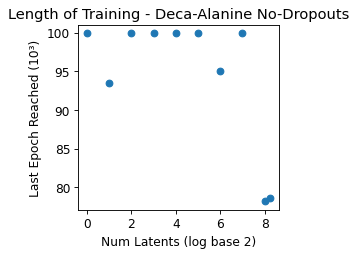

In [15]:
last_epoch_plot(self, f'Length of Training - {system}')

In [18]:
np.log2(np.array((132, 306, 1926, 6531, 9897)))

array([ 7.04439412,  8.25738784, 10.91139199, 12.67308819, 13.27277556])

In [19]:
lsize = [16, 64, 512, 512, 2048]
fsize = [132, 306, 1926, 6531, 9897]
for i in range(5):
    print(100*lsize[i]/fsize[i])

12.121212121212121
20.915032679738562
26.583592938733126
7.839534527637421
20.693139335152065


In [20]:
exp = self.experiments['4 Latents']

In [33]:
rng_seed = 28507

recon, latents = exp.operate(rng_seed)

In [34]:
latents.shape, recon.shape

((2000, 4), (2000, 306))

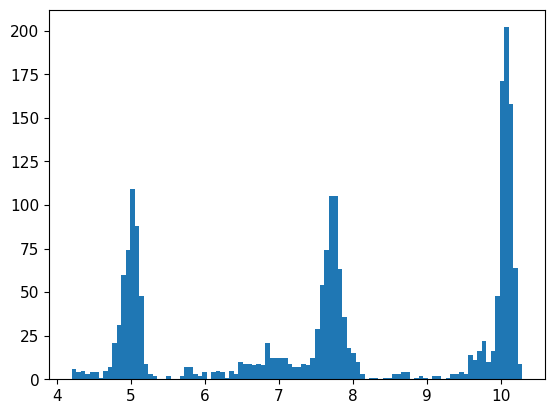

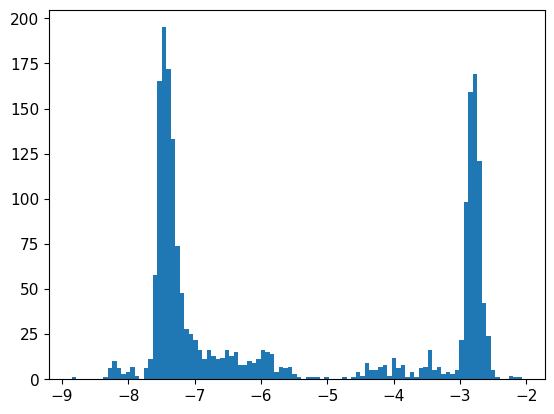

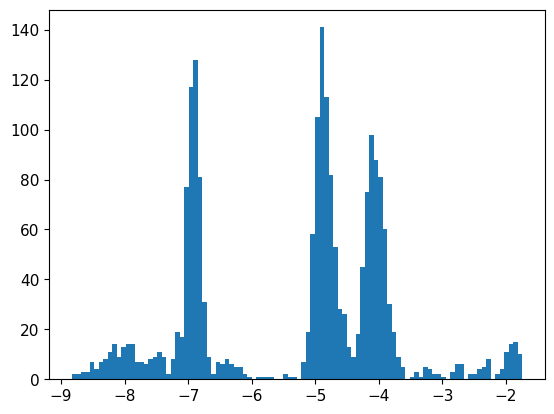

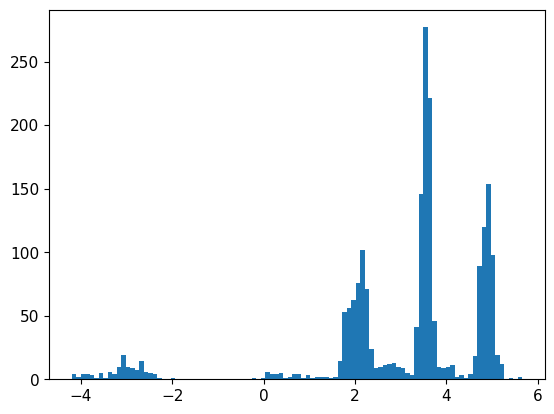

In [35]:
for i in range(latents.shape[-1]):
    plt.clf()
    _ = plt.hist(latents[:, i], bins=100)
    plt.show()

In [36]:
#How much does a perturbation of latent change the atomistic position?
latent_domain_sizes = [np.max(latents[:, i]) - np.min(latents[:, i]) for i in range(latents.shape[-1])]
print(latent_domain_sizes)

[Array(6.09761, dtype=float32), Array(6.7984705, dtype=float32), Array(7.095064, dtype=float32), Array(9.876091, dtype=float32)]


In [37]:
np.sum(np.logspace(-2, 0, 101))

22.0063759853324

(102,)


<Figure size 640x480 with 0 Axes>

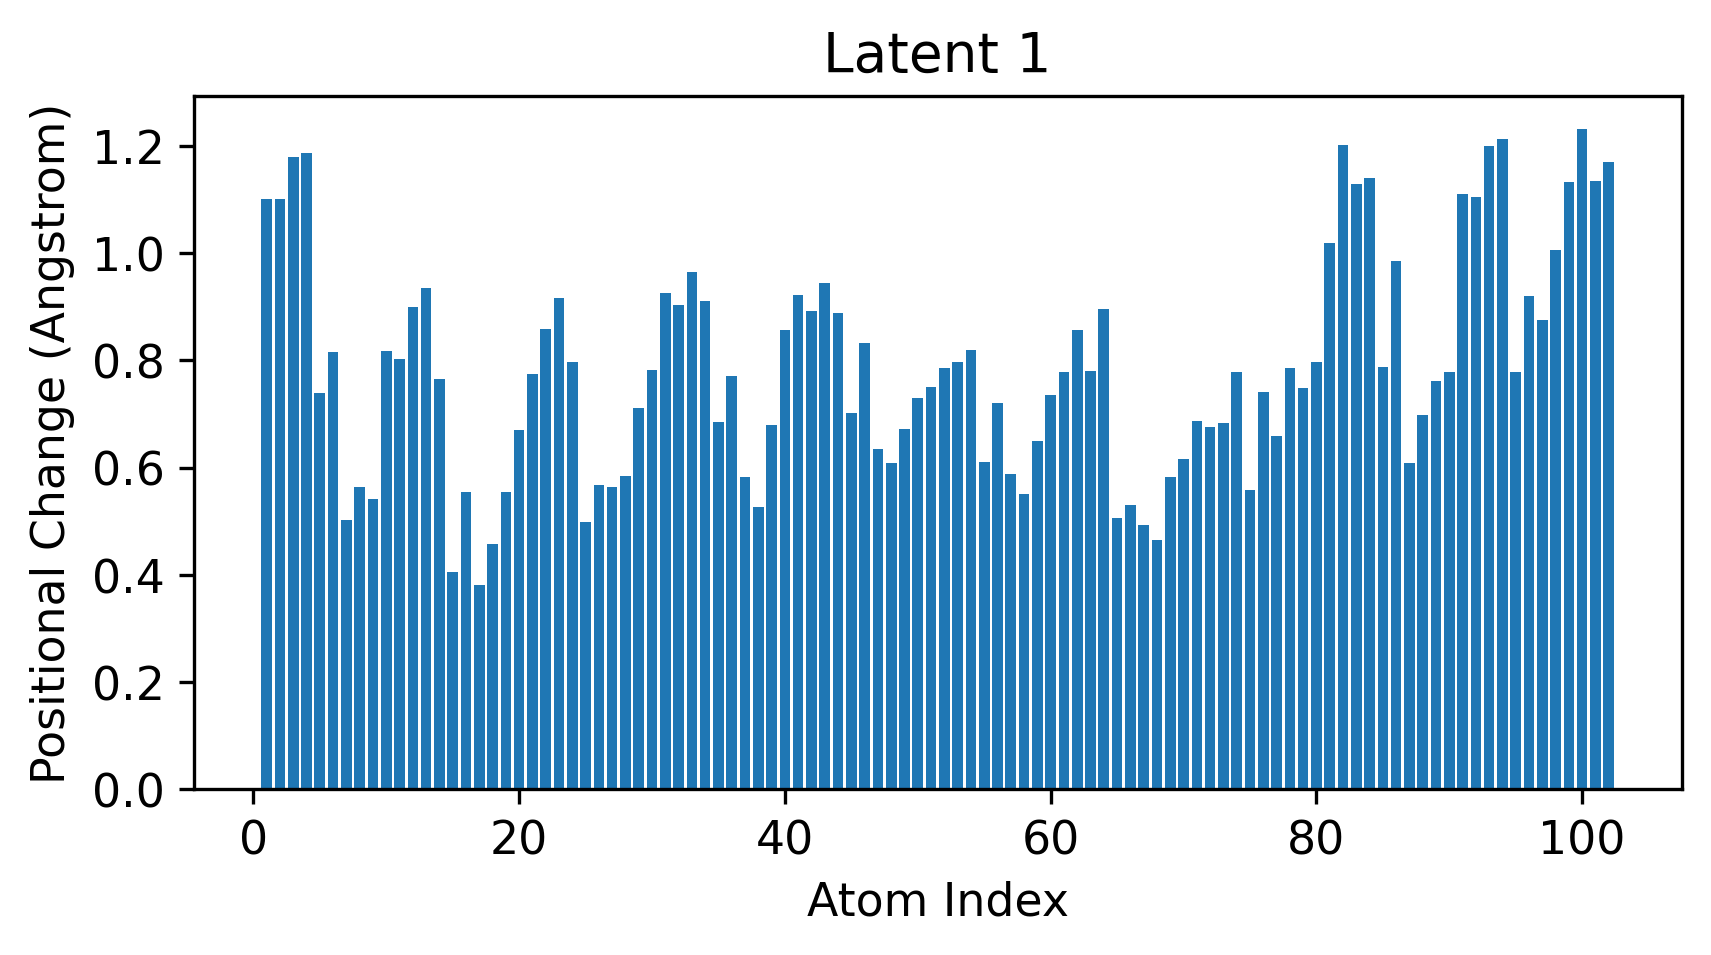

(102,)


<Figure size 640x480 with 0 Axes>

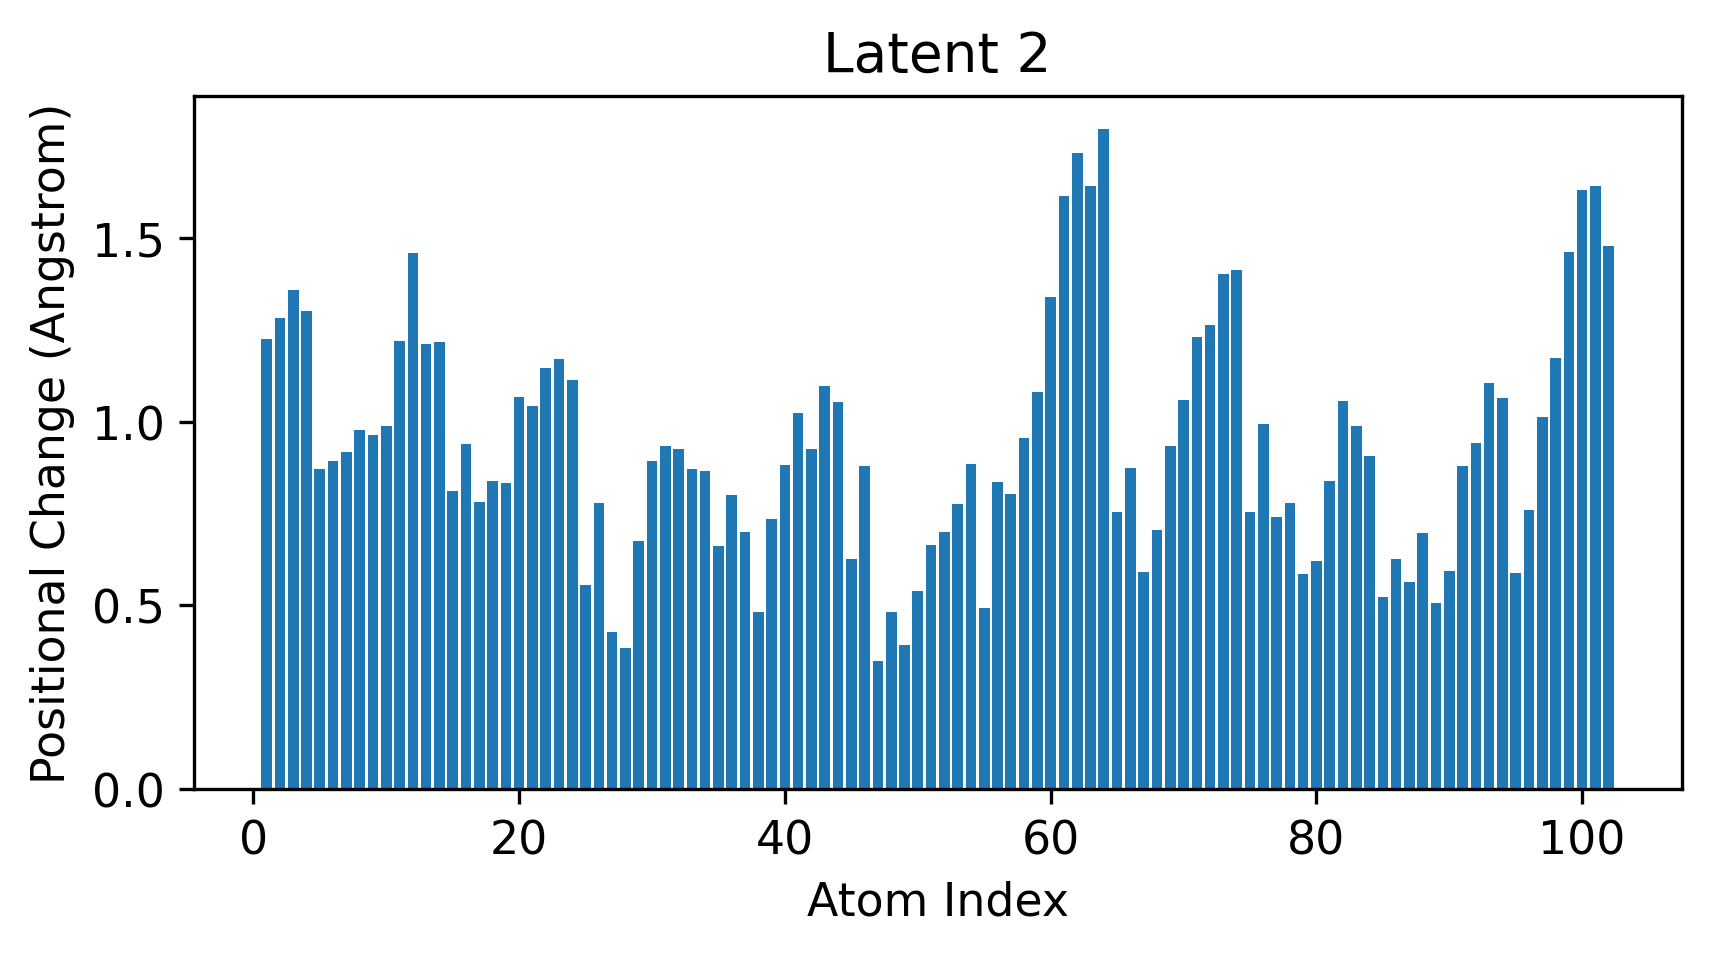

(102,)


<Figure size 640x480 with 0 Axes>

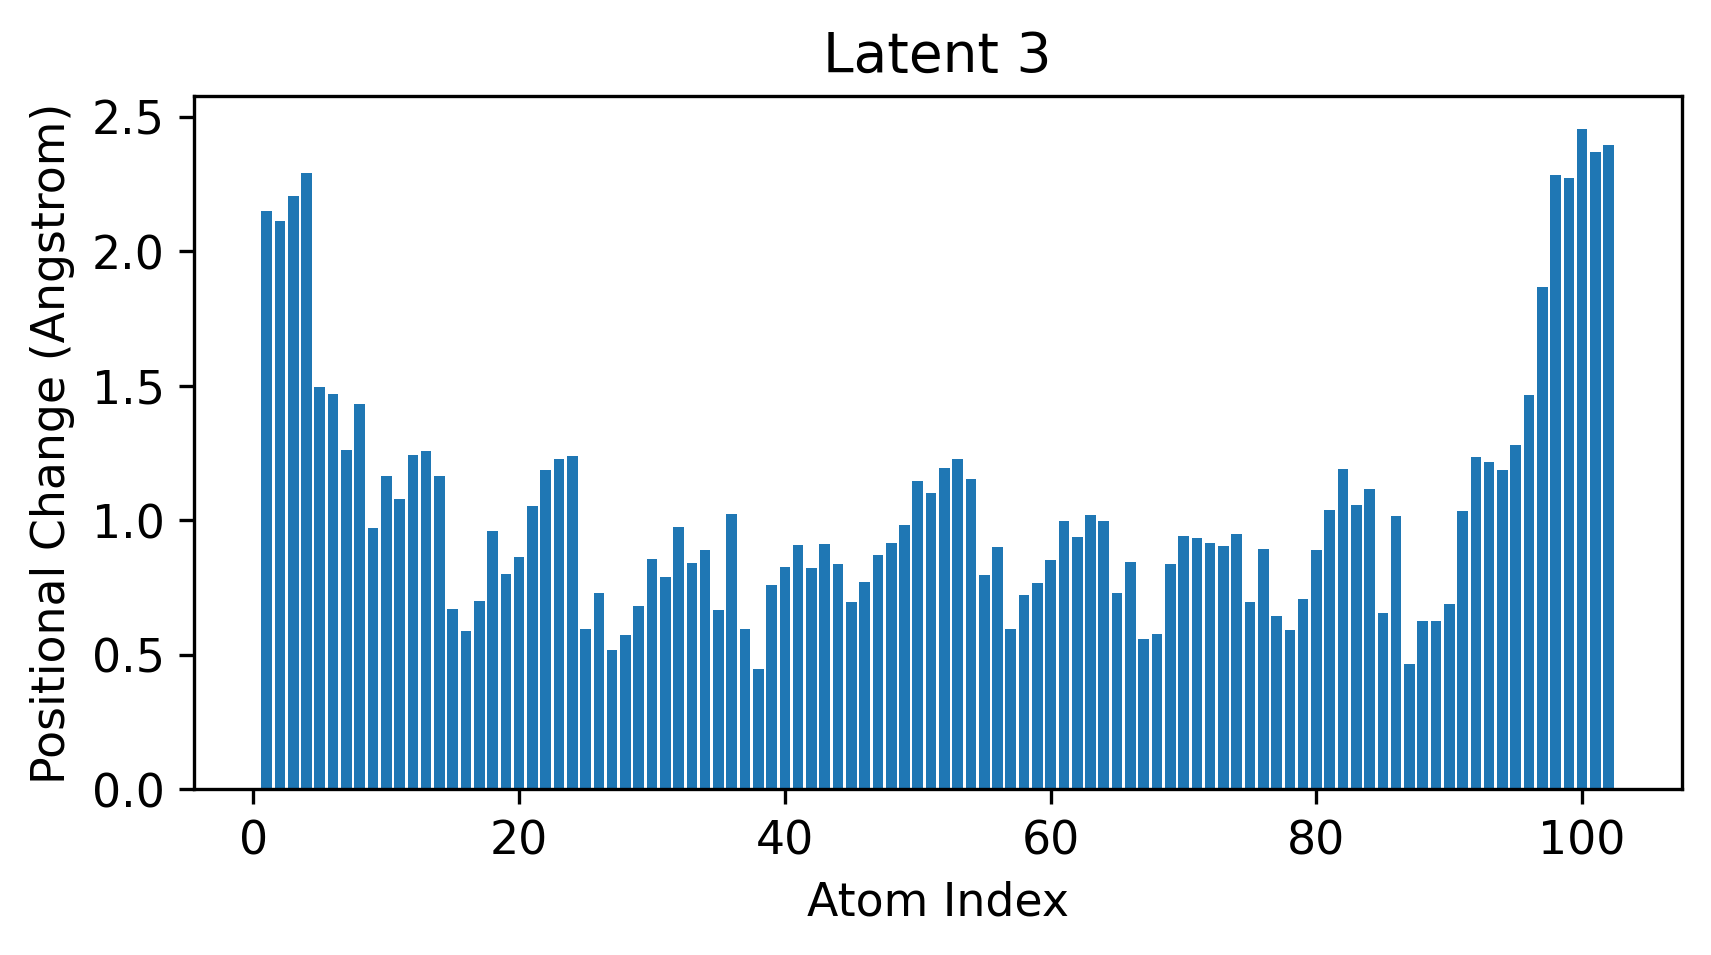

(102,)


<Figure size 640x480 with 0 Axes>

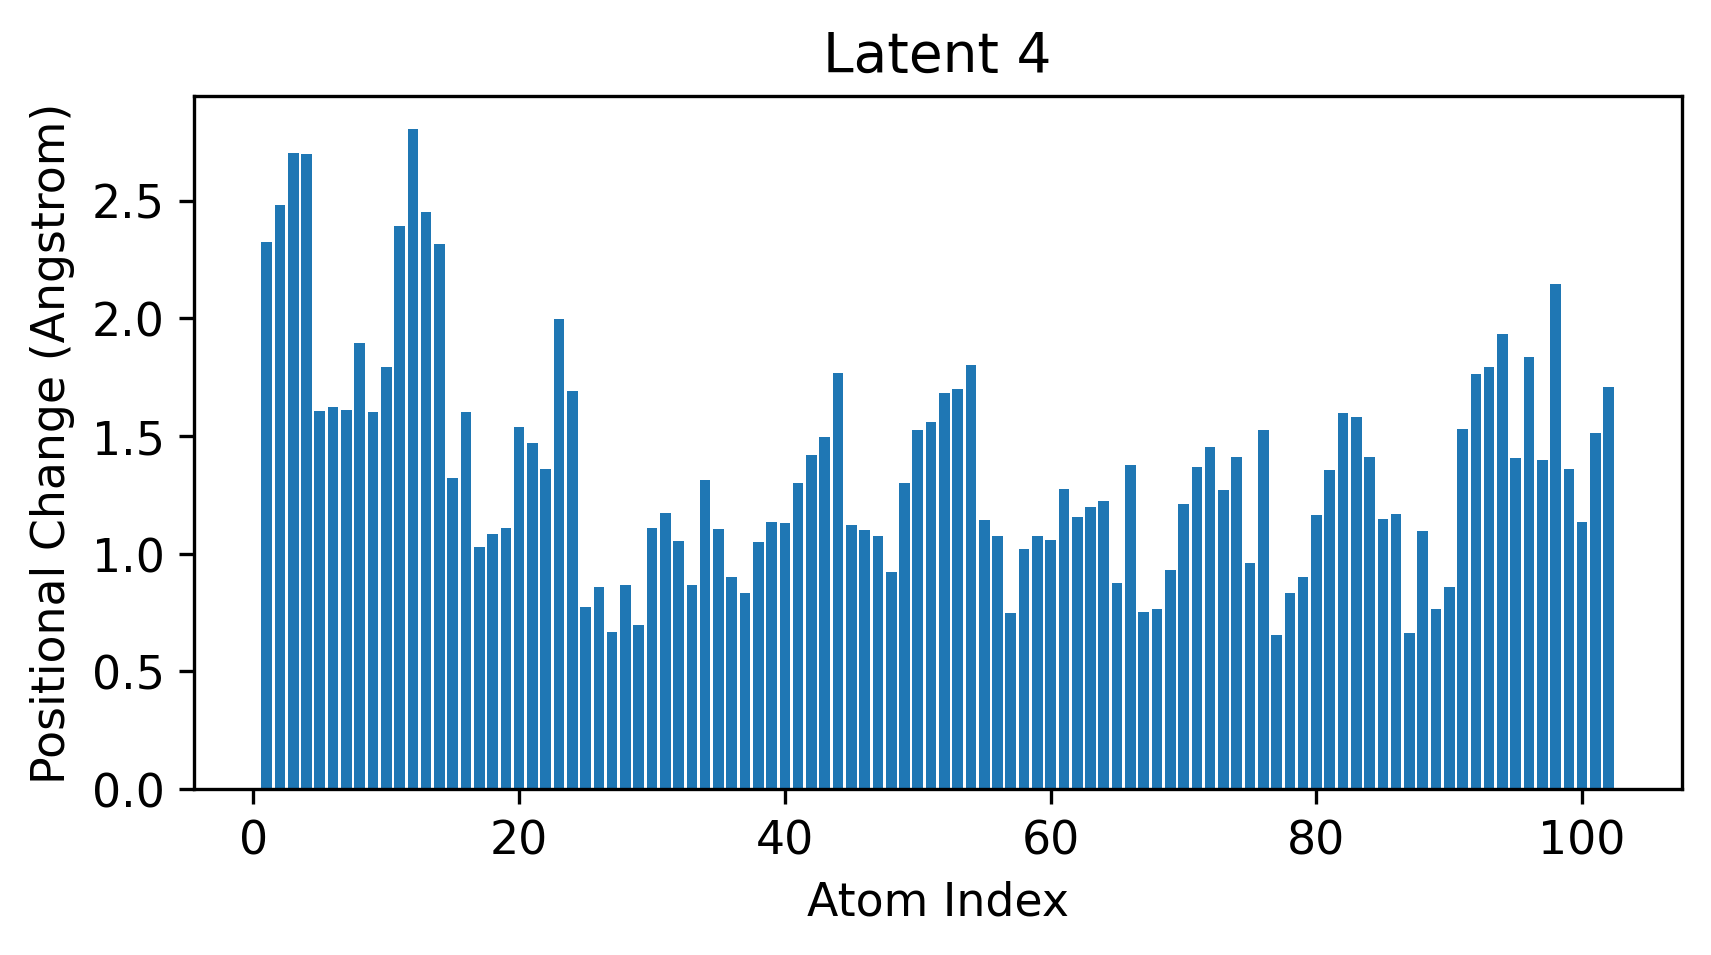

In [75]:
ave_shifts = np.zeros((102,4))

for i in range(4):
    perturbed = latents.at[:, i].add(latent_domain_sizes[i]/10)
    perturbed_recon = exp.decode(rng_seed, perturbed)
    diff_recon = perturbed_recon - recon
    diff_recon = diff_recon.reshape(diff_recon.shape[0], -1, 3)
    Edist = np.sqrt(np.sum(diff_recon**2, axis=2))
    mean_edist = np.mean(Edist, axis=0)
    ave_shifts[:, i] = mean_edist
    print(mean_edist.shape)
    plt.clf()
    _ = plt.figure(figsize=(6.4, 3), dpi=300)
    _ = plt.bar(np.arange(1, 103), mean_edist*10)
    plt.rc('font', **{'weight':'normal', 'size':11})
    plt.title(f'Latent {i+1}')
    plt.xlabel('Atom Index')
    plt.ylabel('Positional Change (Angstrom)')
    plt.savefig(f'DA-4Latents-SuPoL{i+1}.png', dpi=600, bbox_inches = "tight")
    plt.show()
    

In [65]:
import mdtraj as md

In [66]:
traj = md.load('Simulation/ala_deca_peptide.pdb')

In [77]:
i = 0
for atom in traj.top.atoms:
    print(i, atom, atom.is_backbone, *ave_shifts[i, :])
    i += 1

0 ACE1-CH3 False 0.1101028174161911 0.12251421064138412 0.2147696614265442 0.23231065273284912
1 ACE1-H1 False 0.11004886031150818 0.1283206194639206 0.21125592291355133 0.2481675148010254
2 ACE1-H2 False 0.11792919784784317 0.13578826189041138 0.2206411510705948 0.2700669765472412
3 ACE1-H3 False 0.11879585683345795 0.1300843507051468 0.22911541163921356 0.2697374224662781
4 ACE1-C True 0.07383741438388824 0.08714219927787781 0.14935711026191711 0.1607915312051773
5 ACE1-O True 0.08148694038391113 0.08944985270500183 0.14697183668613434 0.16233205795288086
6 ALA2-N True 0.05016513541340828 0.09181888401508331 0.12592366337776184 0.16114798188209534
7 ALA2-H False 0.056297577917575836 0.09774547815322876 0.143205925822258 0.18953445553779602
8 ALA2-CA True 0.05422249436378479 0.09642670303583145 0.09713339805603027 0.16021674871444702
9 ALA2-HA False 0.08181684464216232 0.09874866157770157 0.11637585610151291 0.17929710447788239
10 ALA2-CB False 0.08018386363983154 0.12197054177522659 

In [ ]:
self.potential_violin_plot(rng_seed=98263, title='Potential Energy Error upon Reconstruction - DecaAlanine')

In [7]:
model = self.experiments['4 Latents']
rng_seed = 92183

In [8]:
test_data = model.test_data
recon, _ = model.operate(rng_seed)
_, samples_5 = model.gaussian_mm_fit(rng_seed, 5)

In [9]:
test_ener = gas_fun(test_data)
recon_ener = gas_fun(recon)
ener_5 = gas_fun(model.decode(rng_seed, samples_5))

Outliers above 1000.0 kJ/mol for 4 Latents - 5 Components: 74 (3.7 %)
Outliers above 1000.0 kJ/mol for 4 Latents - 5 Components: 86 (4.3 %)


<Figure size 640x480 with 0 Axes>

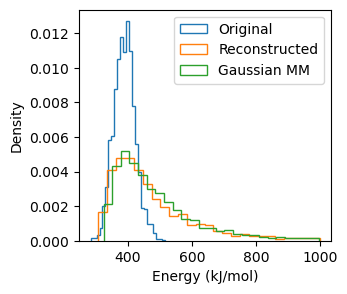

In [10]:
plt.clf()
plt.figure(figsize=(3.25, 3))
threshold = 1e3
plt.hist(test_ener, histtype='step', bins=25, density=True)

num_outliers_recon = recon_ener[recon_ener > threshold].shape[0]
print(f"Outliers above {threshold} kJ/mol for 4 Latents - 5 Components: {num_outliers_recon} ({100*num_outliers_recon/2000} %)")
plt.hist(recon_ener[recon_ener < threshold], histtype='step', bins=25, density=True)

num_outliers_5 = ener_5[ener_5 > threshold].shape[0]
print(f"Outliers above {threshold} kJ/mol for 4 Latents - 5 Components: {num_outliers_5} ({100*num_outliers_5/2000} %)")
plt.hist(ener_5[ener_5 < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(['Original', 'Reconstructed', 'Gaussian MM'])
plt.ylabel('Density')
plt.savefig(f'DA_4_latents_GMM_ener.png', dpi=600, bbox_inches = "tight")
plt.show()

In [ ]:
test, decoded, generated = model.test_decoded_modeled_trajs(rng_seed, 5)

In [ ]:
#Cluster the generated
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
clusters = []
for i in range(2, 10):
    clusters.append(i)
    kmeans = KMeans(n_clusters=i).fit_predict(generated)
    sil_scores.append(silhouette_score(generated, kmeans))

sil_scores = np.array(sil_scores)
clusters = np.array(clusters)


plt.clf()
_ = plt.plot(clusters, sil_scores)
plt.xlabel('Num Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(generated)

In [ ]:
plt.clf()
_ = plt.hist(jnp.log10(gas_fun(generated)), bins=25, histtype='step', density=True)
_ = plt.hist(jnp.log10(gas_fun(test)), bins=25, histtype='step', density=True)
plt.show()

gas_fun(kmeans.cluster_centers_)

In [8]:
model = self.experiments['16 Latents']

In [27]:
variance = lambda x: jnp.sum((x - jnp.mean(x))**2)/x.shape[0]
std_dev = lambda x: jnp.sqrt(variance(x))

def divvy_pdevs(pdevs, n_move):
    return jnp.array([pdevs[i-n_move:i] for i in range(n_move, pdevs.shape[0])])

def calculate_variance_of_pdev(pdevs, n_move):
    pdevs_div = divvy_pdevs(pdevs, n_move)
    return jax.vmap(variance, in_axes=(0))(pdevs_div)

def calculate_stddev_of_pdev(pdevs, n_move):
    pdevs_div = divvy_pdevs(pdevs, n_move)
    return jax.vmap(std_dev, in_axes=(0))(pdevs_div)

2 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3e1f96840>


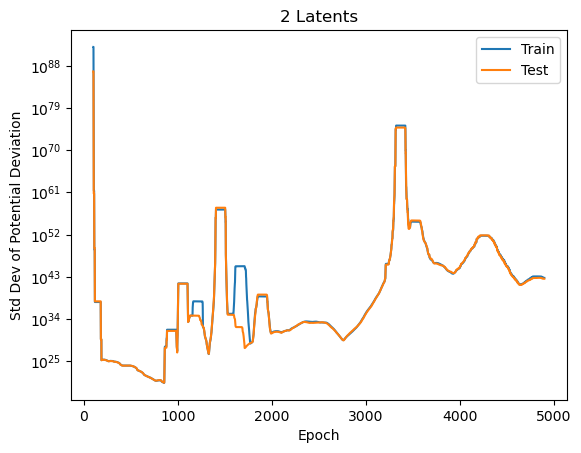

4 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3875d9be0>


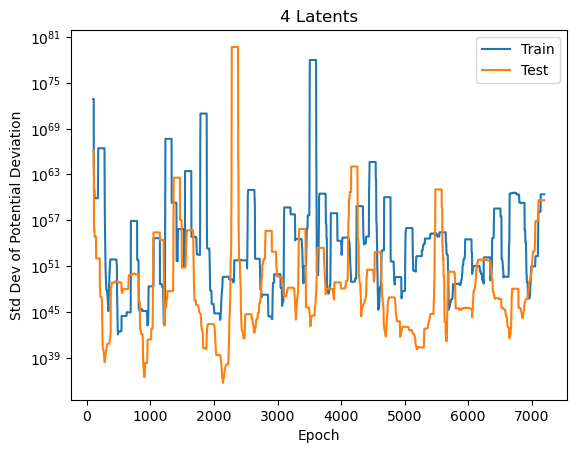

8 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3be1003e0>


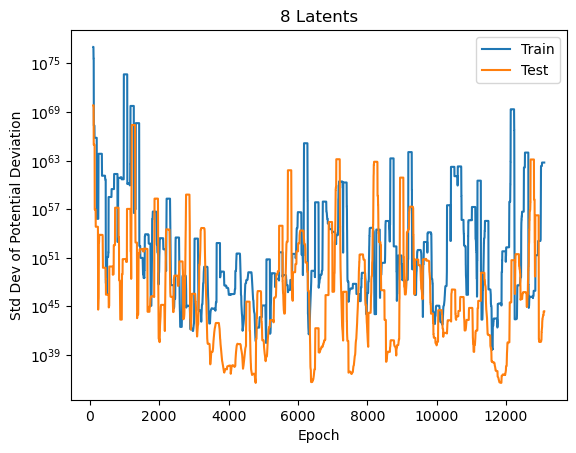

16 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3be11e9c0>


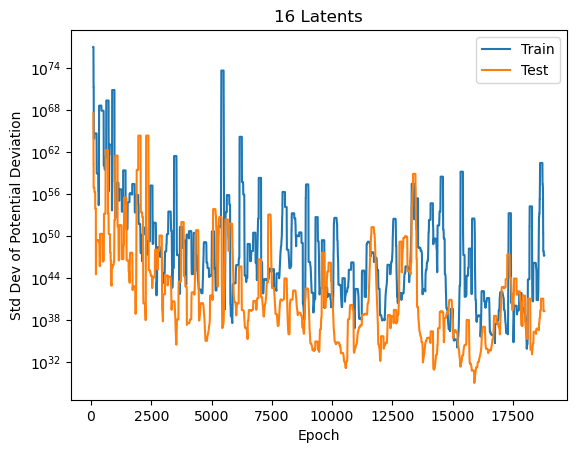

32 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c398cc0410>


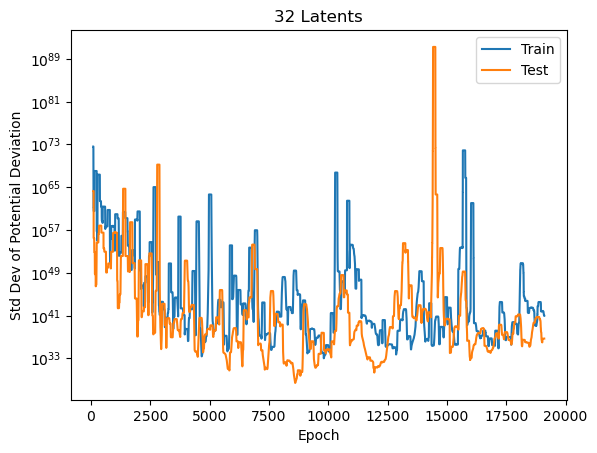

64 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3e1b8d520>


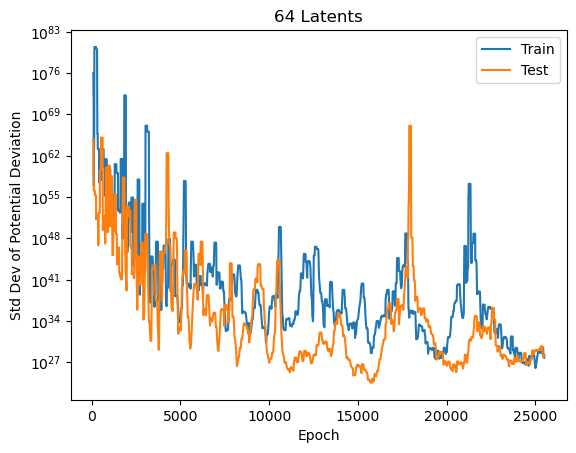

128 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3866d5820>


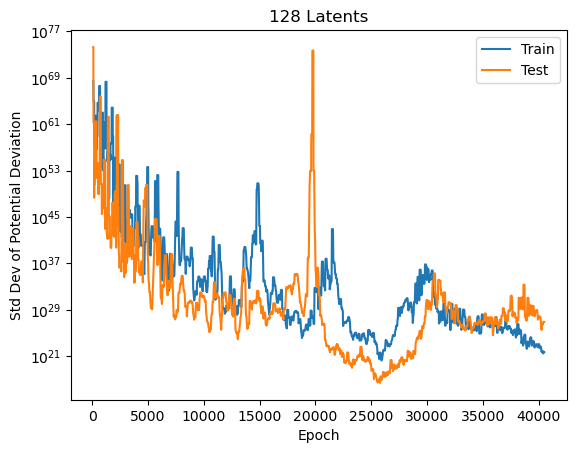

256 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3849eefc0>


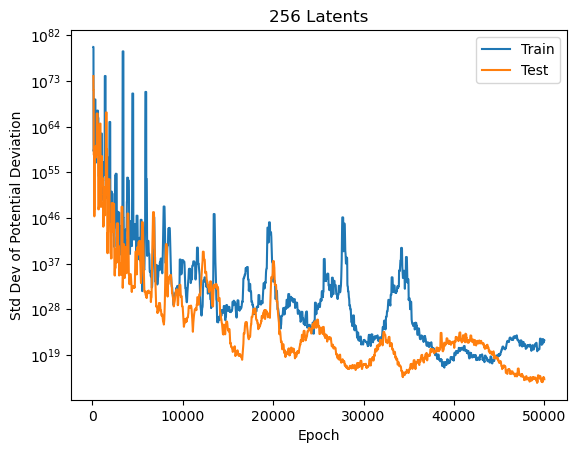

512 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c3e1f14950>


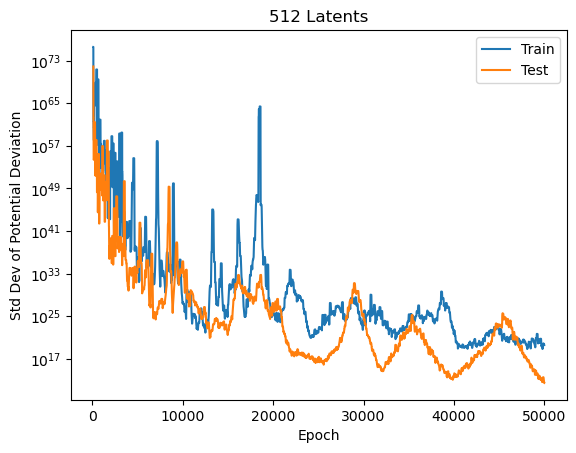

1024 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c386ee7d10>


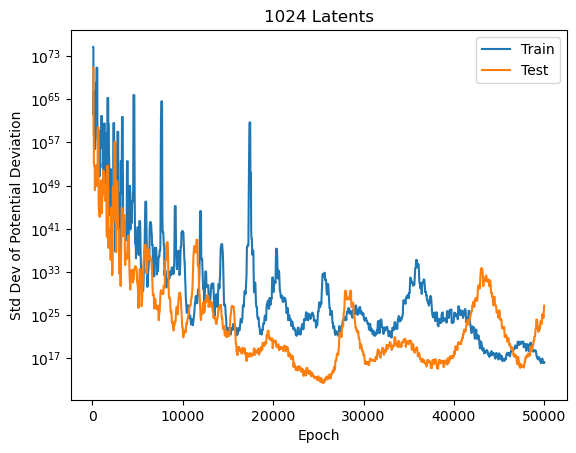

1926 Latents <pyscripts.analysis.NN_Experiment_Analyzer object at 0x74c398d455e0>


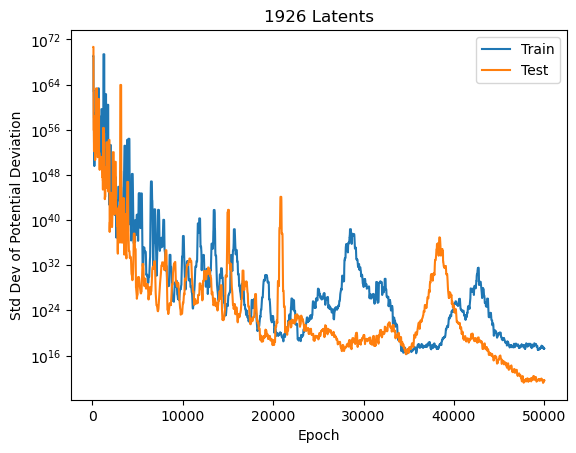

In [31]:
n_move = 100

for key, exp in self.experiments.items():
    print(key, exp)
    pdevs_train = jnp.mean(np.array(exp.rootgrp['Train'].variables['Potential']), axis=1)
    pdevs_test = jnp.mean(np.array(exp.rootgrp['Test'].variables['Potential']), axis=1)
    vars_train = calculate_stddev_of_pdev(pdevs_train, n_move)
    vars_test = calculate_stddev_of_pdev(pdevs_test, n_move)

    plt.clf()
    _ = plt.plot(jnp.arange(n_move, vars_train.shape[0] + n_move), vars_train)
    _ = plt.plot(jnp.arange(n_move, vars_test.shape[0] + n_move), vars_test)
    plt.title(key)
    plt.ylabel('Std Dev of Potential Deviation')
    plt.legend(['Train', 'Test'])
    plt.xlabel('Epoch')
    plt.yscale('log')
    plt.savefig(f'std_dev_of_potential_deviation_{key}.png')
    plt.show()    

In [ ]:
n_move = 10

for key, exp in self.experiments.items():
    print(key, exp)
    pdevs_train = jnp.mean(np.array(exp.rootgrp['Train'].variables['Potential']), axis=1)
    pdevs_test = jnp.mean(np.array(exp.rootgrp['Test'].variables['Potential']), axis=1)
    vars_train = calculate_stddev_of_pdev(pdevs_train, n_move)
    vars_test = calculate_stddev_of_pdev(pdevs_test, n_move)

    plt.clf()
    _ = plt.plot(jnp.arange(n_move, vars_train.shape[0] + n_move), vars_train)
    _ = plt.plot(jnp.arange(n_move, vars_test.shape[0] + n_move), vars_test)
    plt.title(key)
    plt.ylabel('Std Dev of Potential Deviation')
    plt.xlabel('Epoch')
    plt.yscale('log')
    plt.show()

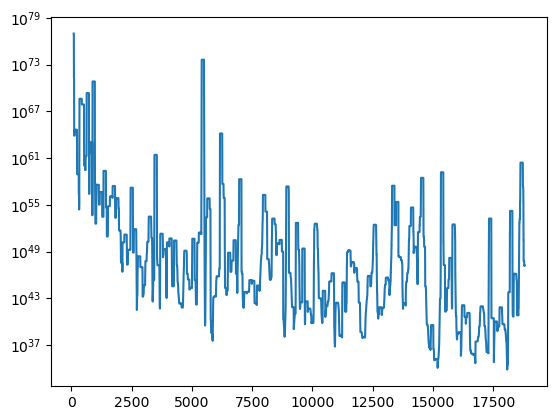

In [13]:
plt.clf()
_ = plt.plot(jnp.arange(100, vars.shape[0]+100), jnp.sqrt(vars))
plt.yscale('log')
plt.show()

In [ ]:
fname = f'{model.model_name}{model.n_latents:04d}_GMM_sample_cluster_centers.dcd'
traj_xyz = kmeans.cluster_centers_.reshape(kmeans.cluster_centers_.shape[0], -1, 3)
with md.formats.DCDTrajectoryFile(fname, 'w') as f:
    f.write(traj_xyz*10)

In [ ]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Double Digits Latents
plt.clf()
n_latents = 100
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Triple Digits Latents
plt.clf()
n_latents = 1000
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        _, samples = exp.gaussian_mm_fit(rng_seed, 5)
        recon = exp.decode(rng_seed, samples)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
A, B = self.super_traj_construct()

In [ ]:
rmsd = jax.vmap(atom_rmsd)(A, B)

In [ ]:
plt.clf()
_ = plt.plot(jnp.arange(rmsd.shape[0]), rmsd*10)
plt.vlines(jnp.array((500,1000,1500,2000,2500,3000,3500,4000)), jnp.array([0.025]*8), jnp.array([2.5]*8), colors='r')
plt.ylabel('RMSD (A)')
plt.ylim(0.1, 2)
plt.show()

In [ ]:
def write_traj(fname, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
    if traj_xyz.shape[-1] != 3:
        traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
    
    with md.formats.DCDTrajectoryFile(fname, 'w') as f:
        f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but writes it as angstrom (charmdcd standard is angstrom)

In [ ]:
write_traj('Test_Data_Super.dcd', A)
write_traj('Decoded_Data_Super.dcd', B)

In [ ]:
#Write a PDB for visualization with OpenMM

In [ ]:
from openmm import *
from openmm.app import *
from openmm.unit import *

In [ ]:
prmtop = AmberPrmtopFile('Simulation/1crn_H.prmtop')

In [ ]:
positions = A[0, :].reshape(-1, 3)

In [ ]:
with open('1crn_H.pdb', 'w') as f:
    PDBFile.writeModel(prmtop.topology, positions*10, file=f)